In [4]:
# ── Cell 1: Imports, Folders & Load Everything ──
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics     import roc_curve, auc, confusion_matrix
from joblib              import load

# Helper to ensure a path is a directory (delete if it’s a file)
def ensure_dir(path):
    if os.path.exists(path):
        if not os.path.isdir(path):
            os.remove(path)        # remove the file
            os.makedirs(path)      # create folder
    else:
        os.makedirs(path)

# Ensure outputs and models folders exist
ensure_dir("../outputs")
ensure_dir("../models")

# Load raw data
raw    = pd.read_csv("../data/synthetic_er_data.csv", parse_dates=["arrival_time"])
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Load tuned model
model_path = "../models/best_rf.joblib"
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at {model_path}. Run the save cell in model_training.ipynb.")
best_rf = load(model_path)

print("✅ Data and model loaded successfully.")


✅ Data and model loaded successfully.


✅ ROC curve saved to ../outputs/roc_curve.png


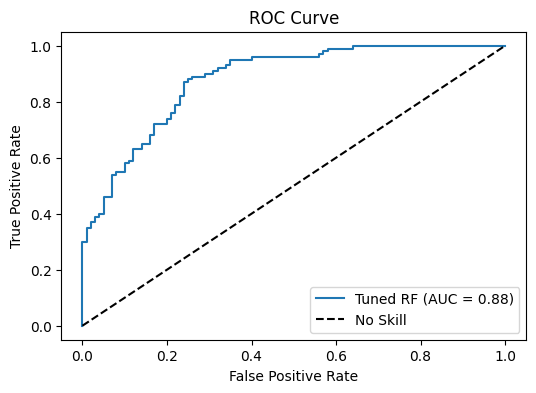

In [5]:
# ── Cell 2: ROC Curve ──
# Compute ROC
probs = best_rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"Tuned RF (AUC = {roc_auc:.2f})")
plt.plot([0,1],[0,1], "k--", label="No Skill")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")

# Save
roc_out = "../outputs/roc_curve.png"
plt.savefig(roc_out, dpi=150, bbox_inches="tight")
print(f"✅ ROC curve saved to {roc_out}")

plt.show()


✅ Feature importances saved to ../outputs/feature_importances.png


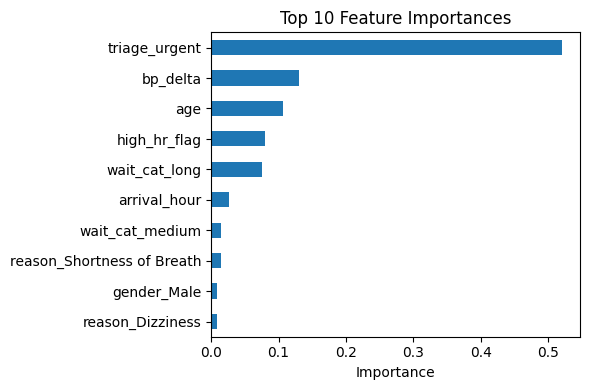

In [6]:
# ── Cell 3: Top 10 Feature Importances ──
# Compute importances
fi = pd.Series(best_rf.feature_importances_, index=X_test.columns)
fi = fi.sort_values(ascending=False).head(10)

# Plot horizontal bar chart
plt.figure(figsize=(6,4))
fi[::-1].plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()

# Save
fi_out = "../outputs/feature_importances.png"
plt.savefig(fi_out, dpi=150, bbox_inches="tight")
print(f"✅ Feature importances saved to {fi_out}")

plt.show()


✅ Confusion matrix saved to ../outputs/confusion_matrix.png


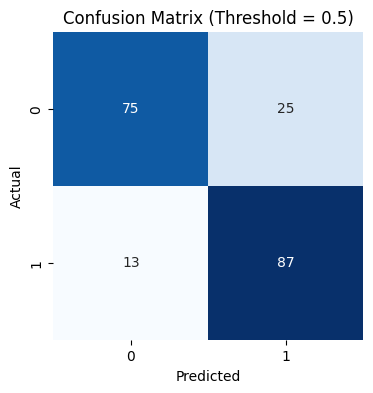

In [7]:
# ── Cell 4: Confusion Matrix at 0.5 Threshold ──
# Predict with threshold = 0.5
y_pred = (probs > 0.5).astype(int)
cm     = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Threshold = 0.5)")

# Save
cm_out = "../outputs/confusion_matrix.png"
plt.savefig(cm_out, dpi=150, bbox_inches="tight")
print(f"✅ Confusion matrix saved to {cm_out}")

plt.show()


C:\Users\spoor\AppData\Local\Temp\ipykernel_20912\3004525643.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  arrival_counts = raw.set_index("arrival_time").resample("H").size()


✅ Arrival time series saved to ../outputs/arrival_time_series.png


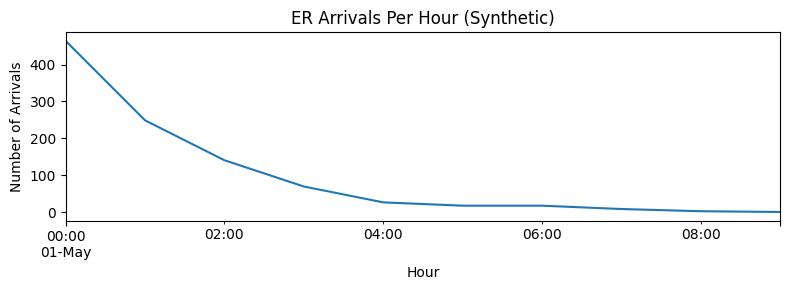

In [8]:
# ── Cell 5: ER Arrival Time Series ──
# Count arrivals per hour
arrival_counts = raw.set_index("arrival_time").resample("H").size()

# Plot
plt.figure(figsize=(8,3))
arrival_counts.plot()
plt.xlabel("Hour")
plt.ylabel("Number of Arrivals")
plt.title("ER Arrivals Per Hour (Synthetic)")
plt.tight_layout()

# Save
ts_out = "../outputs/arrival_time_series.png"
plt.savefig(ts_out, dpi=150, bbox_inches="tight")
print(f"✅ Arrival time series saved to {ts_out}")

plt.show()
